In [1]:
import warnings
warnings.filterwarnings('ignore')   # keep the notebook output readable

import glob
import logging
import os

import matplotlib as mpl
import matplotlib.patheffects  # noqa: F401, outlined labels
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray  # noqa: F401, registers the .rio accessor
from rasterio.warp import transform

import GRSl2bgen

logging.getLogger().setLevel(logging.WARNING)

# lighter figures for the documentation
%config InlineBackend.figure_formats = ['jpeg']
plt.rcParams['figure.dpi'] = 72

print(f'GRSl2bgen {GRSl2bgen.__version__}')

GRSl2bgen 1.0.0


In [2]:
l2a_path = ('/data/tmp/grstbx_subset/loire_estuary/'
            'S2A_MSIL2AGRS_20170412T110621_N0500_R137_T30TWT_20231111T110836_V3.0.1dev_loire_estuary.zarr')

# group '0' = full resolution of the multiscale store
prod = GRSl2bgen.Product(xr.open_zarr(l2a_path, group='0', decode_coords='all'))
raster = prod.raster

# keep the valid water pixels only (mask == 0)
Rrs = raster.Rrs.where(raster.mask == 0).load()
date = str(raster.time.dt.strftime('%Y-%m-%d').values)
dx, dy = (abs(r) for r in raster.rio.resolution())
print(f'{date}: {raster.sizes["y"]} x {raster.sizes["x"]} pixels of {dx:.0f} x {dy:.0f} m, '
      f'bands {Rrs.wl.values.tolist()} nm')

2017-04-12: 1762 x 1761 pixels of 20 x 20 m, bands [443, 490, 560, 665, 705, 740, 783, 842, 865, 1610, 2190] nm


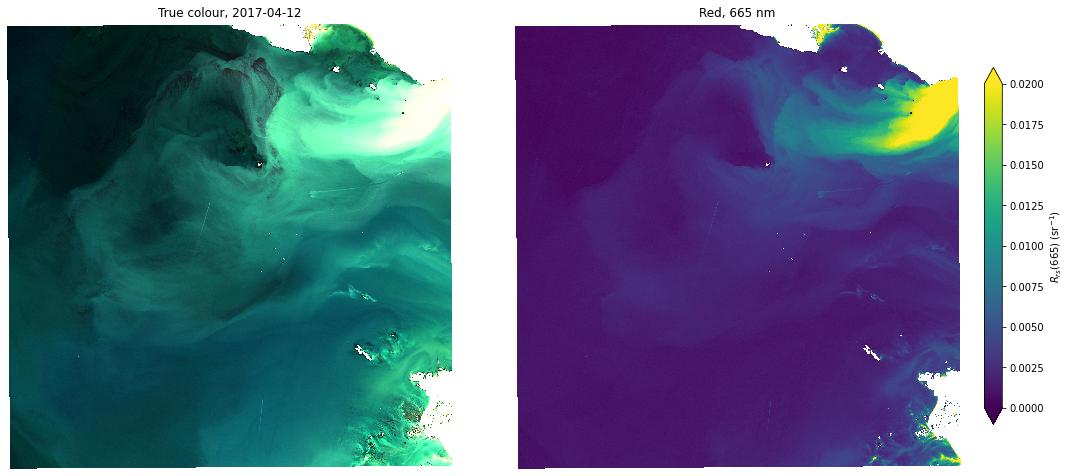

In [3]:
def show_map(ax, title):
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_axis_off()

rgb = Rrs.sel(wl=[665, 560, 490])
fig, axs = plt.subplots(1, 2, figsize=(15, 6.5), constrained_layout=True)
rgb.plot.imshow(rgb='wl', robust=True, ax=axs[0])
show_map(axs[0], f'True colour, {date}')
Rrs.sel(wl=665).plot.imshow(vmin=0, vmax=0.02, cmap='viridis', ax=axs[1],
                            cbar_kwargs={'label': r'$R_{rs}(665)$ (sr$^{-1}$)', 'shrink': 0.8})
show_map(axs[1], 'Red, 665 nm')

In [4]:
points = {
    'offshore':      (523000, 5230000),
    'dark filament': (530500, 5232500),
    'shelf':         (535000, 5215000),
    'south shelf':   (540000, 5207000),
    'plume edge':    (540000, 5230000),
    'plume':         (546000, 5228000),
    'plume core':    (553000, 5228500),
    'Bourgneuf bay': (552000, 5203500),
    'north coast':   (549000, 5234500),
}

half = 1.5 * dx   # half-width of the 3 x 3 window
spectra = []
for name, (x, y) in points.items():
    window = Rrs.sel(x=slice(x - half, x + half), y=slice(y + half, y - half))
    spectra.append(window.median(['x', 'y']).assign_coords(owt=name))

xowt_img = xr.concat(spectra, dim='owt').reset_coords(drop=True).transpose('owt', 'wl')
xowt_img.name = 'Rrs'
names = xowt_img.owt.values
Nowt = len(names)
colors = plt.get_cmap('tab10')(np.arange(Nowt))
cmap_img = mpl.colors.ListedColormap(colors)
xowt_img

<xarray.DataArray 'Rrs' (owt: 9, wl: 11)> Size: 792B
array([[ 2.9150e-03,  3.2350e-03,  2.8500e-03,  5.3000e-04,  4.8000e-04,
         2.8000e-04,  5.7000e-04,  5.8000e-04,  3.5500e-04,  7.0000e-05,
        -6.0000e-05],
       [ 2.4550e-03,  2.6850e-03,  2.6600e-03,  8.2500e-04,  6.5500e-04,
         4.5000e-04,  5.8000e-04,  6.4000e-04,  5.9000e-04,  6.0000e-05,
        -6.5000e-05],
       [ 5.1150e-03,  6.8450e-03,  7.2100e-03,  1.7850e-03,  1.2300e-03,
         5.9000e-04,  7.6500e-04,  7.6500e-04,  4.4000e-04,  9.0000e-05,
        -1.4000e-04],
       [ 6.2700e-03,  8.2100e-03,  7.4200e-03,  1.3200e-03,  9.6500e-04,
         6.9500e-04,  7.8500e-04,  8.1000e-04,  5.5500e-04,  1.1000e-04,
        -7.0000e-05],
       [ 6.8450e-03,  9.1100e-03,  1.0275e-02,  4.5800e-03,  3.4100e-03,
         1.1250e-03,  1.3450e-03,  1.3300e-03,  1.0650e-03,  8.0000e-05,
        -9.0000e-05],
       [ 1.0160e-02,  1.5065e-02,  2.0280e-02,  9.6550e-03,  6.9900e-03,
         2.2900e-03,  2.5150e-03,  2.1800e-03,  1.3750e-03,  9.0000e-05,
        -9.5000e-05],
       [ 1.2325e-02,  1.8755e-02,  2.8305e-02,  2.3230e-02,  1.9745e-02,
         6.7550e-03,  6.7500e-03,  5.6550e-03,  3.6350e-03,  1.2000e-04,
        -1.2500e-04],
       [ 8.5950e-03,  1.4035e-02,  1.9730e-02,  6.2150e-03,  4.0650e-03,
         2.1200e-03,  2.4850e-03,  2.2350e-03,  2.2600e-03,  2.7000e-04,
        -1.3000e-04],
       [ 4.8650e-03,  8.0450e-03,  1.1960e-02,  3.1750e-03,  2.4250e-03,
         1.8400e-03,  2.1800e-03,  1.9600e-03,  1.8650e-03,  2.1000e-04,
        -2.5000e-05]])
Coordinates:
  * owt      (owt) <U13 468B 'offshore' 'dark filament' ... 'north coast'
  * wl       (wl) int64 88B 443 490 560 665 705 740 783 842 865 1610 2190
Attributes: (12/15)
    acquisition_date:           20170412T110621
    cloud_cover:                0.0
    condensed_name:             20170412T110621_S2_T30TWT_L1C_110836
    constellation:              Sentinel-2
    constellation_id:           S2
    gas_absorption_correction:  True
    ...                         ...
    path:                       /tmp/tmpo8eu2z1g/tmp_20170412T110621_S2_T30TW...
    product_filename:           S2A_MSIL1C_20170412T110621_N0500_R137_T30TWT_...
    product_name:               S2A_MSIL1C_20170412T110621_N0500_R137_T30TWT_...
    product_path:               /data/satellite/Sentinel-2/L1C/30TWT/2017/04/...
    product_type:               MSIL1C
    radiometry:                 reflectance

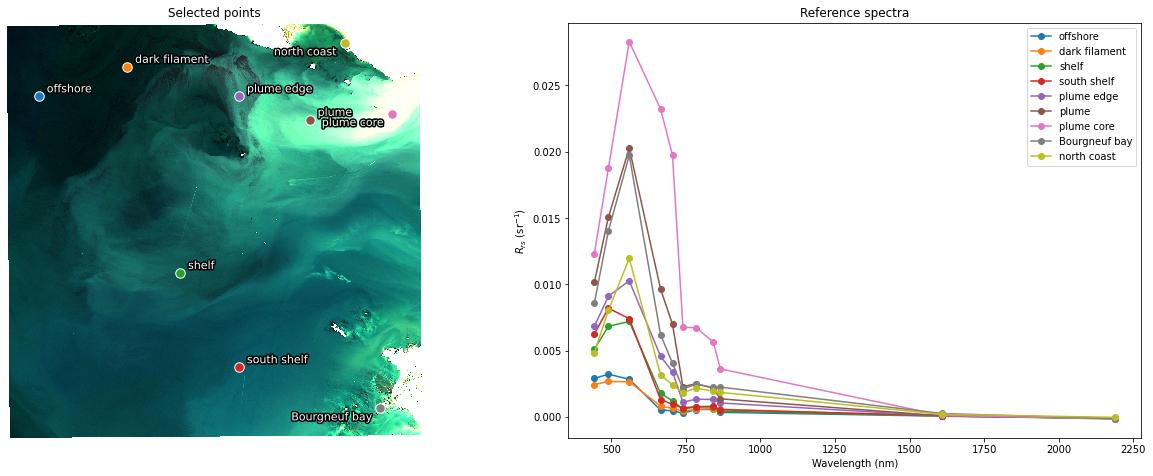

In [5]:
outline = [mpl.patheffects.withStroke(linewidth=3, foreground='black')]
fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True)
rgb.plot.imshow(rgb='wl', robust=True, ax=axs[0])
for i, (name, (x, y)) in enumerate(points.items()):
    axs[0].scatter(x, y, color=colors[i], edgecolor='white', s=90, zorder=10)
    right = x > 548000   # points close to the eastern edge: label on their left
    axs[0].annotate(name, (x, y), xytext=(-8 if right else 8, -12 if right else 4),
                    textcoords='offset points', ha='right' if right else 'left',
                    color='white', fontsize=11, path_effects=outline)
show_map(axs[0], 'Selected points')

for i, name in enumerate(names):
    xowt_img.sel(owt=name).plot(ax=axs[1], color=colors[i], marker='o', label=name)
axs[1].set_title('Reference spectra')
axs[1].set_xlabel('Wavelength (nm)')
axs[1].set_ylabel(r'$R_{rs}$ (sr$^{-1}$)')
axs[1].legend(fontsize=10);

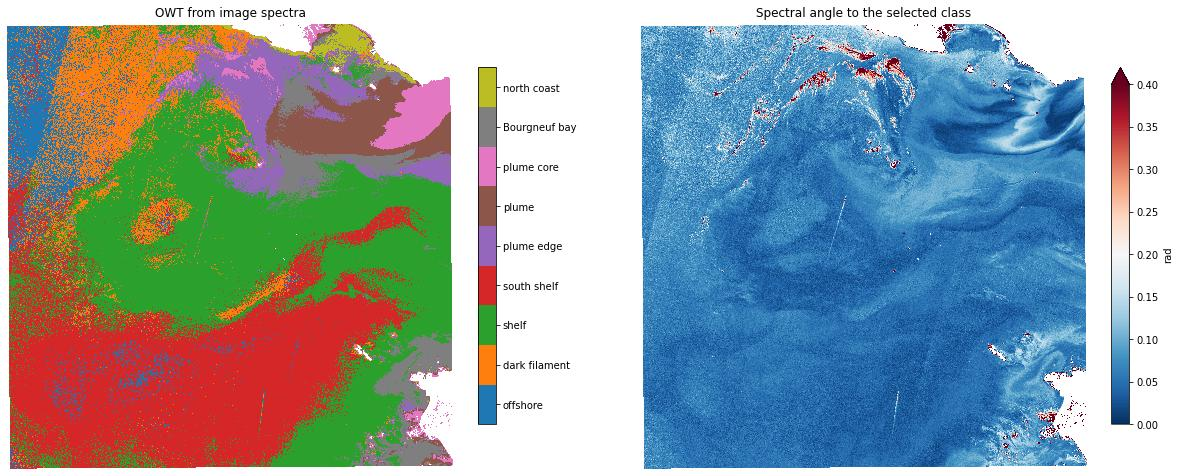

In [6]:
owt_img = GRSl2bgen.OWT(raster, xowt=xowt_img)
xowt_prod = owt_img.multi_process().where(raster.mask == 0).compute()

def show_owt(ax, prod, labels, cmap, title):
    """Map an OWT index with the class names on the colour bar."""
    n = len(labels)
    im = prod.owt_index.plot.imshow(ax=ax, cmap=cmap, vmin=0.5, vmax=n + 0.5,
                                    cbar_kwargs={'ticks': range(1, n + 1), 'shrink': 0.8, 'label': ''})
    im.colorbar.ax.set_yticklabels(labels)
    show_map(ax, title)

fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True)
show_owt(axs[0], xowt_prod, names, cmap_img, 'OWT from image spectra')
xowt_prod.owt_dist.plot.imshow(ax=axs[1], cmap='RdBu_r', vmin=0, vmax=0.4,
                               cbar_kwargs={'label': 'rad', 'shrink': 0.8})
show_map(axs[1], 'Spectral angle to the selected class')

,pixels,area (km2),share (%)
OWT,,,
offshore,188128,75.25,6.39
dark filament,284682,113.87,9.67
shelf,1036247,414.50,35.20
south shelf,861253,344.50,29.26
plume edge,186113,74.45,6.32
plume,128981,51.59,4.38
plume core,77729,31.09,2.64
Bourgneuf bay,153083,61.23,5.20
north coast,27440,10.98,0.93


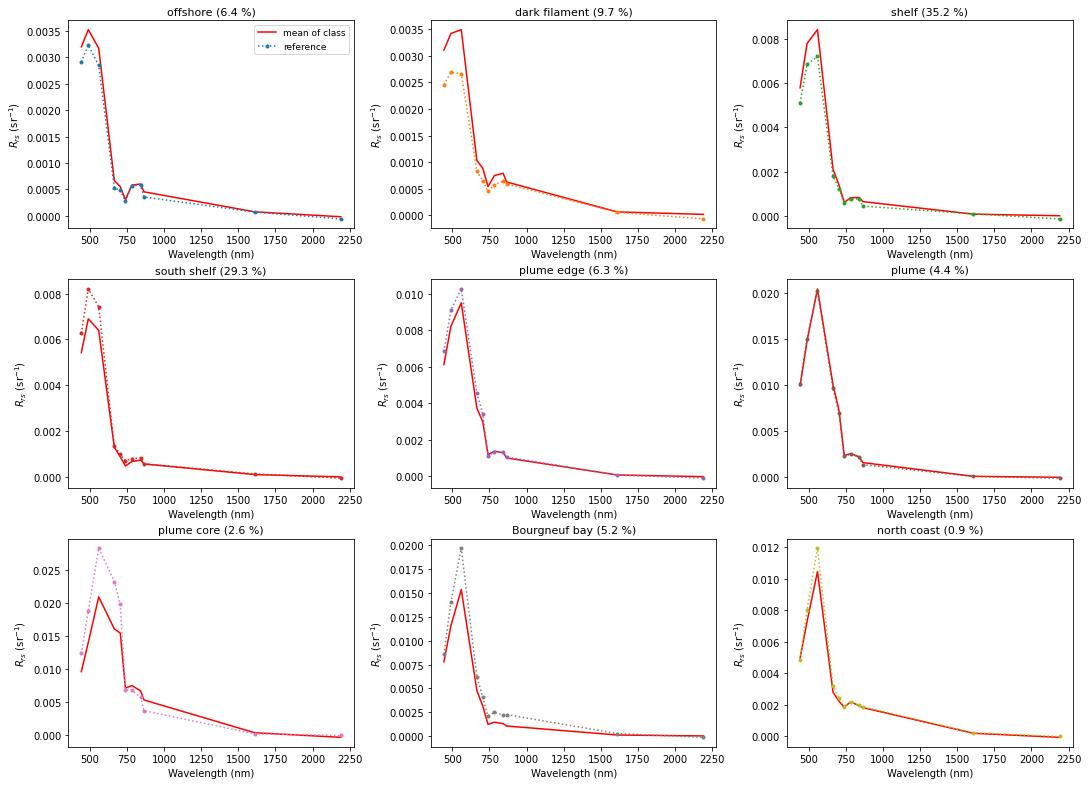

In [7]:
pixel_area_km2 = dx * dy * 1e-6
index = xowt_prod.owt_index
Ntot = int(index.count())

ncols = 3
nrows = int(np.ceil(Nowt / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), constrained_layout=True)
rows = []
for j, (ax, name) in enumerate(zip(axs.ravel(), names), start=1):
    Rrs_j = Rrs.where(index == j)
    Npix = int(Rrs_j.isel(wl=0).count())
    rows.append({'OWT': name, 'pixels': Npix, 'area (km2)': Npix * pixel_area_km2,
                 'share (%)': 100 * Npix / Ntot})
    if Npix:
        Rrs_j.mean(['x', 'y']).plot(ax=ax, color='r', label='mean of class')
    xowt_img.sel(owt=name).plot(ax=ax, color=colors[j - 1], ls=':', marker='o', ms=3, label='reference')
    ax.set_title(f'{name} ({100 * Npix / Ntot:.1f} %)', fontsize=11)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel(r'$R_{rs}$ (sr$^{-1}$)')
axs.ravel()[0].legend(fontsize=9)
for ax in axs.ravel()[Nowt:]:
    ax.set_axis_off()
pd.DataFrame(rows).set_index('OWT').round(2)

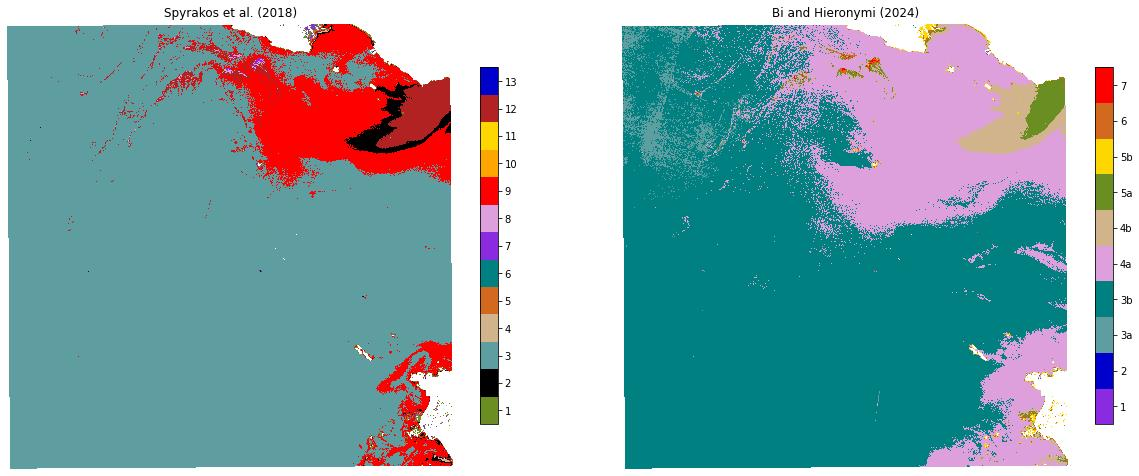

In [8]:
owt_spy = GRSl2bgen.OWT(raster, owt_database='Spyrakos2018')
prod_spy = owt_spy.multi_process().where(raster.mask == 0).compute()
owt_bi = GRSl2bgen.OWT(raster, owt_database='Bi2024')
prod_bi = owt_bi.multi_process().where(raster.mask == 0).compute()

fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True)
show_owt(axs[0], prod_spy, [str(i) for i in range(1, 14)], owt_spy.cmap_owt, 'Spyrakos et al. (2018)')
show_owt(axs[1], prod_bi, ['1', '2', '3a', '3b', '4a', '4b', '5a', '5b', '6', '7'], owt_bi.cmap_owt,
         'Bi and Hieronymi (2024)')

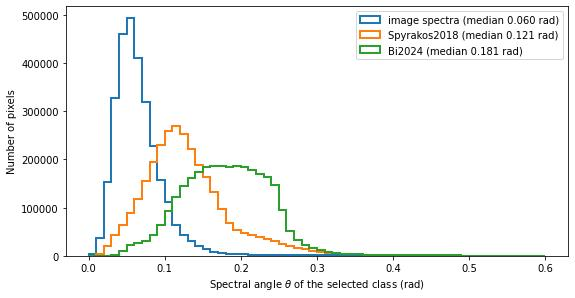

In [9]:
angles = {'image spectra': xowt_prod.owt_dist, 'Spyrakos2018': prod_spy.owt_dist, 'Bi2024': prod_bi.owt_dist}
bins = np.linspace(0, 0.6, 61)
fig, ax = plt.subplots(figsize=(9, 4.5))
for label, da in angles.items():
    values = da.values.ravel()
    values = values[np.isfinite(values)]
    ax.hist(values, bins=bins, histtype='step', lw=2, label=f'{label} (median {np.median(values):.3f} rad)')
ax.set_xlabel(r'Spectral angle $\theta$ of the selected class (rad)')
ax.set_ylabel('Number of pixels')
ax.legend();

In [10]:
owt_dir = '/DATA/data/model/owt'

gernez = []
for file in sorted(glob.glob(os.path.join(owt_dir, 'Gernez_50_shades_Rrs_cluster_*.txt'))):
    name = file.split('_')[-1].replace('.txt', '')
    # one column per in situ spectrum of the cluster
    cluster = pd.read_csv(file, sep=r'\s+').set_index('wavelength').stack().to_xarray()
    gernez.append(cluster.median('level_1').assign_coords(owt=name))
gernez = xr.concat(gernez, 'owt').rename({'wavelength': 'wl'}).reset_coords(drop=True)
print(gernez.owt.values, 'at', gernez.wl.values, 'nm')

['Cyanobacteria' 'Dinoflagellates1' 'Dinoflagellates2' 'Lepidodinium'
 'Mesodinium' 'red'] at [443 492 560 665 704 740 783 834 865] nm


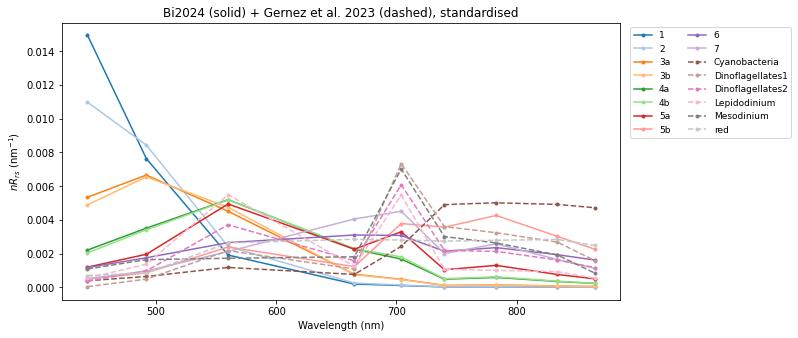

In [11]:
def standardise(spectra):
    return spectra / spectra.integrate('wl')

bi = owt_bi.owt.interp(wl=gernez.wl)          # Bi2024 standardised mean spectra (m_nRrs)
bi['owt'] = ['1', '2', '3a', '3b', '4a', '4b', '5a', '5b', '6', '7']
xowt_comb = xr.concat([bi, gernez], dim='owt').dropna('wl')
names_comb = xowt_comb.owt.values
Ncomb = len(names_comb)
cmap_comb = mpl.colors.ListedColormap(plt.get_cmap('tab20')(np.arange(Ncomb)))

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(names_comb):
    standardise(xowt_comb).sel(owt=name).plot(ax=ax, color=cmap_comb(i), marker='o', ms=3,
                                 ls='-' if i < 10 else '--', label=name)
ax.set_title('Bi2024 (solid) + Gernez et al. 2023 (dashed), standardised')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$nR_{rs}$ (nm$^{-1}$)')
ax.legend(ncol=2, fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left');

In [12]:
ta2025 = xr.open_dataarray(GRSl2bgen.owt.OWT_tarasenko2025_file)
print('same classes:', sorted(ta2025.owt.values) == sorted(names_comb))
print('same spectra:', np.allclose(ta2025.transpose('owt', 'wl').values,
                                   xowt_comb.sel(owt=ta2025.owt.values).values, rtol=1e-6))
# class numbers used in owt_index_Ta2025
pd.Series(ta2025.owt.values, index=range(1, len(ta2025.owt) + 1), name='Ta2025 class').to_frame().T

same classes: True
same spectra: True


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
Ta2025 class,1,2,3a,3b,4a,4b,5a,5b,6,7,Cyanobacteria,Mesodinium,Dinoflagellates2,red,Dinoflagellates1,Lepidodinium


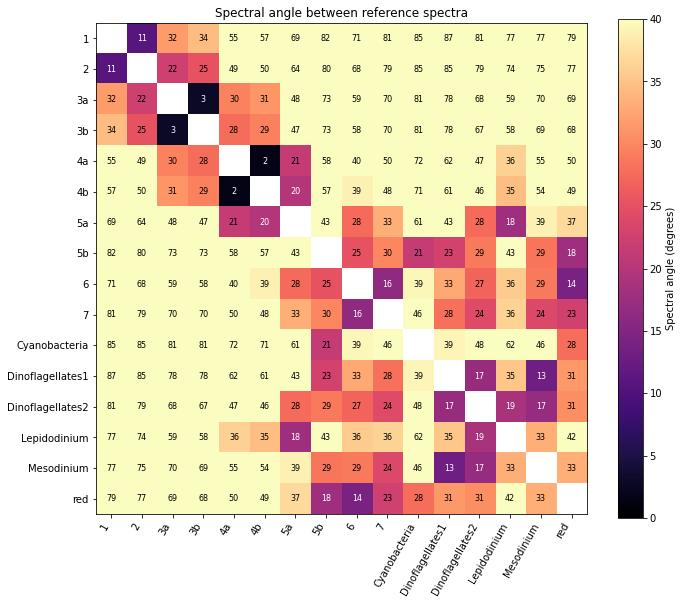

In [13]:
unit = xowt_comb / np.sqrt((xowt_comb ** 2).sum('wl'))
cosines = np.clip(unit.values @ unit.values.T, -1, 1)
angle_matrix = pd.DataFrame(np.degrees(np.arccos(cosines)), index=names_comb, columns=names_comb)
np.fill_diagonal(angle_matrix.values, np.nan)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(angle_matrix, cmap='magma', vmin=0, vmax=40)
ax.set_xticks(range(Ncomb), names_comb, rotation=60, ha='right')
ax.set_yticks(range(Ncomb), names_comb)
for i in range(Ncomb):
    for j in range(Ncomb):
        if i != j:
            ax.text(j, i, f'{angle_matrix.iat[i, j]:.0f}', ha='center', va='center', fontsize=8,
                    color='white' if angle_matrix.iat[i, j] < 20 else 'black')
fig.colorbar(im, ax=ax, label='Spectral angle (degrees)')
ax.set_title('Spectral angle between reference spectra');

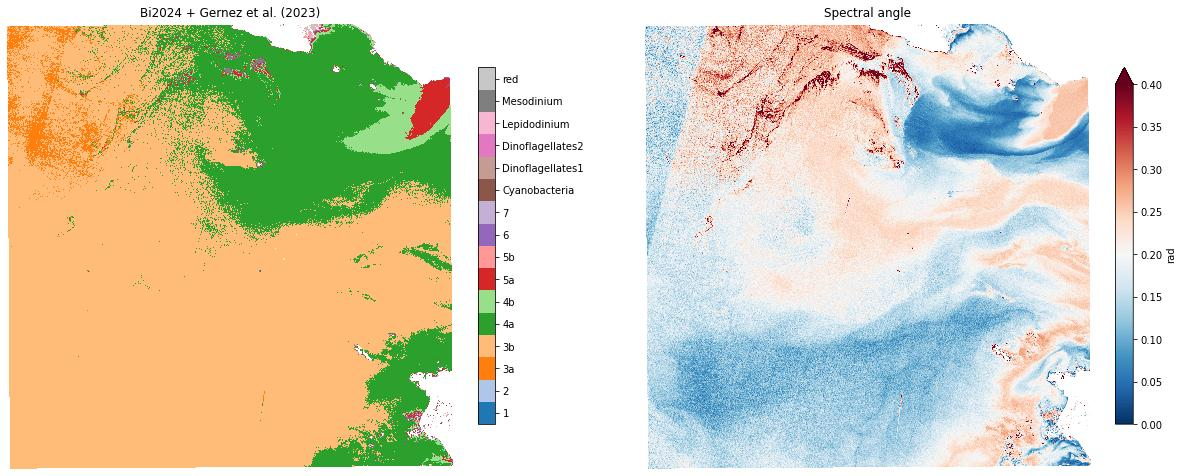

In [14]:
owt_comb = GRSl2bgen.OWT(raster, xowt=xowt_comb)
prod_comb = owt_comb.multi_process().where(raster.mask == 0).compute()

fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True)
show_owt(axs[0], prod_comb, names_comb, cmap_comb, 'Bi2024 + Gernez et al. (2023)')
prod_comb.owt_dist.plot.imshow(ax=axs[1], cmap='RdBu_r', vmin=0, vmax=0.4,
                               cbar_kwargs={'label': 'rad', 'shrink': 0.8})
show_map(axs[1], 'Spectral angle')

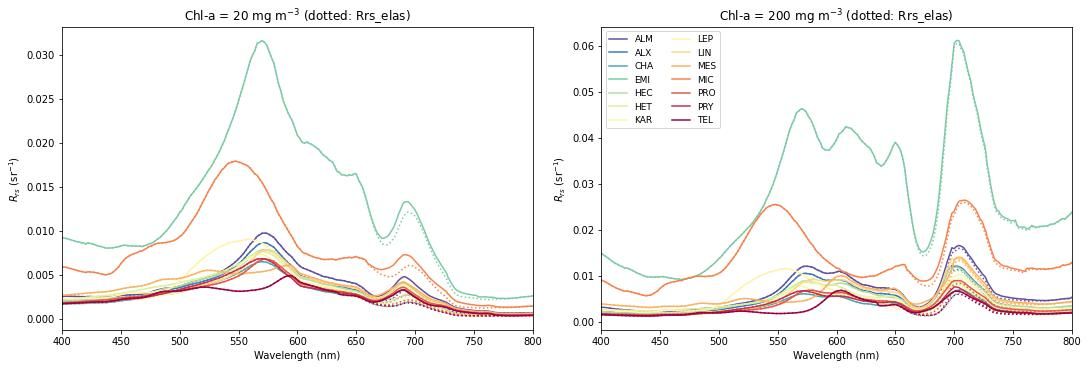

In [15]:
hablab = xr.open_dataset(os.path.join(owt_dir, 'hablab_owt_chl20_chl_200.nc'))
species = hablab.species.values
cmap_sp = plt.get_cmap('Spectral_r')

fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=False, constrained_layout=True)
for ax, chl in zip(axs, hablab.chl.values):
    for i, sp in enumerate(species):
        color = cmap_sp(i / (len(species) - 1))
        sel = hablab.sel(chl=chl, species=sp)
        sel.Rrs_elas.plot(ax=ax, color=color, ls=':')
        sel.Rrs_tot.plot(ax=ax, color=color, label=sp)
    ax.set_title(f'Chl-a = {chl} mg m$^{{-3}}$ (dotted: Rrs_elas)')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel(r'$R_{rs}$ (sr$^{-1}$)')
    ax.set_xlim(400, 800)
axs[1].legend(ncol=2, fontsize=9);

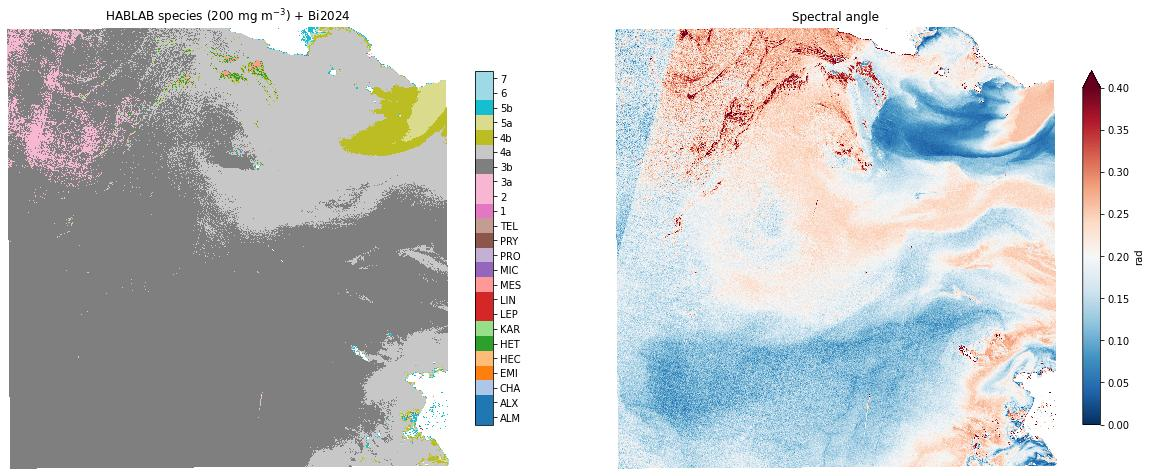

In [16]:
sp_200 = hablab.Rrs_tot.sel(chl=200).rename({'species': 'owt'}).reset_coords(drop=True)
xowt_hab = standardise(xr.concat([sp_200.interp(wl=gernez.wl), bi], dim='owt').dropna('wl'))
names_hab = xowt_hab.owt.values
cmap_hab = mpl.colors.ListedColormap(plt.get_cmap('tab20', len(names_hab))(np.arange(len(names_hab))))

owt_hab = GRSl2bgen.OWT(raster, xowt=xowt_hab)
prod_hab = owt_hab.multi_process().where(raster.mask == 0).compute()

fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True)
show_owt(axs[0], prod_hab, names_hab, cmap_hab, 'HABLAB species (200 mg m$^{-3}$) + Bi2024')
prod_hab.owt_dist.plot.imshow(ax=axs[1], cmap='RdBu_r', vmin=0, vmax=0.4,
                              cbar_kwargs={'label': 'rad', 'shrink': 0.8})
show_map(axs[1], 'Spectral angle')

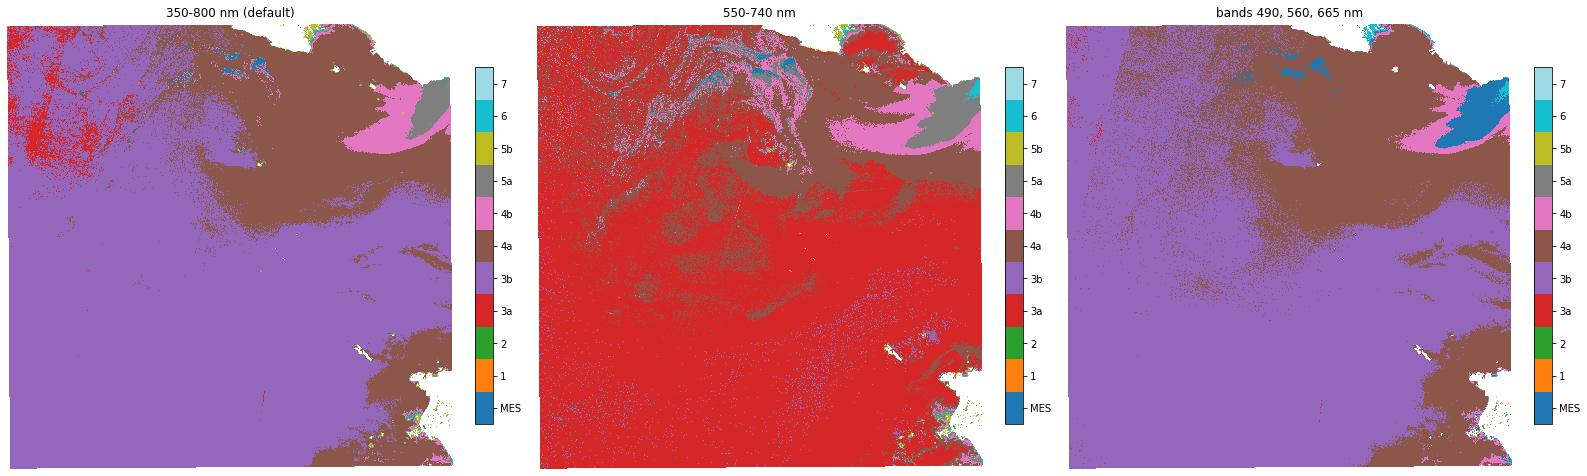

In [17]:
xowt_mes = standardise(xr.concat([sp_200.sel(owt=['MES']).interp(wl=gernez.wl), bi], dim='owt').dropna('wl'))
names_mes = xowt_mes.owt.values
cmap_mes = mpl.colors.ListedColormap(plt.get_cmap('tab20', len(names_mes))(np.arange(len(names_mes))))

fig, axs = plt.subplots(1, 3, figsize=(22, 6.5), constrained_layout=True)
settings = [('350-800 nm (default)', raster, {}),
            ('550-740 nm', raster, {'wl_range': slice(550, 740)}),
            ('bands 490, 560, 665 nm', raster.sel(wl=[490, 560, 665]), {})]
for ax, (title, image, kwargs) in zip(axs, settings):
    prod = GRSl2bgen.OWT(image, xowt=xowt_mes, **kwargs).multi_process().where(raster.mask == 0).compute()
    show_owt(ax, prod, names_mes, cmap_mes, title)